In [1]:
# ── Cell 1: Mount Drive & Imports ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report

print("Libraries loaded.")


Mounted at /content/drive
Libraries loaded.


In [2]:
# ── Cell 2: Paths ─────────────────────────────────────────────────────────────
DATA_DIR      = "/content/drive/MyDrive/disaster_project/disaster_data"
ENSEMBLE_DIR  = "/content/drive/MyDrive/disaster_project/ensemble_results"
RESULTS_DIR   = "/content/drive/MyDrive/disaster_project/disagreement_analysis"
CONFIDENCE_DIR = "/content/drive/MyDrive/disaster_project/confidence_results"
os.makedirs(CONFIDENCE_DIR, exist_ok=True)


In [3]:
# ── Cell 3: Load Label Mapping ────────────────────────────────────────────────
with open(f"{DATA_DIR}/label_mapping.json") as f:
    mapping = json.load(f)

label2id    = mapping["label2id"]
id2label    = {int(k): v for k, v in mapping["id2label"].items()}
NUM_LABELS  = len(label2id)
CLASS_NAMES = [id2label[i] for i in range(NUM_LABELS)]
SHORT_NAMES = [
    "caution", "displaced", "infrastructure", "injured", "missing",
    "not_humanitarian", "other", "requests", "rescue", "sympathy"
]


In [4]:
# ── Cell 4: Load Ensemble Predictions (Test Set) ──────────────────────────────
test_data    = np.load(f"{ENSEMBLE_DIR}/ensemble_predictions.npz")
test_probs   = test_data["probs"]    # [N x 10] softmax probabilities
test_preds   = test_data["preds"]    # [N] predicted class indices
test_labels  = test_data["labels"]   # [N] true class indices
N            = len(test_labels)

print(f"Test set loaded: {N} samples")
print(f"Ensemble Macro F1 (no threshold): {f1_score(test_labels, test_preds, average='macro'):.4f}")


Test set loaded: 15160 samples
Ensemble Macro F1 (no threshold): 0.7690


In [5]:
# ── Cell 5: Load Validation Set Predictions ───────────────────────────────────
# We calibrate the threshold on the VALIDATION set, not the test set
# This prevents data leakage — threshold is tuned without seeing test labels

# We need to run the ensemble on the validation set predictions
# Load individual model validation predictions
MODEL_NAMES = ["RoBERTa", "DeBERTa", "ELECTRA"]
weight_matrix = np.load(f"{ENSEMBLE_DIR}/weight_matrix.npy")  # [3 x 10]

val_preds_per_model = {}
for name in MODEL_NAMES:
    path = f"{RESULTS_DIR}/{name.lower()}_predictions.npz"
    data = np.load(path)
    val_preds_per_model[name] = data

# NOTE: The .npz files contain TEST set predictions from the disagreement script.
# For proper calibration we use the test set with a held-out split.
# We split test into calibration (50%) and evaluation (50%) sets.
# This is a standard practice when no separate calibration set is available.

np.random.seed(42)
indices      = np.random.permutation(N)
calib_idx    = indices[:N // 2]
eval_idx     = indices[N // 2:]

calib_probs  = test_probs[calib_idx]
calib_labels = test_labels[calib_idx]
calib_preds  = test_preds[calib_idx]

eval_probs   = test_probs[eval_idx]
eval_labels  = test_labels[eval_idx]
eval_preds   = test_preds[eval_idx]

print(f"Calibration set: {len(calib_idx)} samples")
print(f"Evaluation set:  {len(eval_idx)} samples")


Calibration set: 7580 samples
Evaluation set:  7580 samples


In [6]:
# ── Cell 6: Confidence Score Definition ──────────────────────────────────────
# Confidence = max softmax probability of the ensemble output
# High confidence → model is certain → predict
# Low confidence  → model is uncertain → abstain (flag as "uncertain")

calib_confidence = calib_probs.max(axis=1)
eval_confidence  = eval_probs.max(axis=1)

print(f"\nCalibration set confidence stats:")
print(f"  Mean : {calib_confidence.mean():.4f}")
print(f"  Std  : {calib_confidence.std():.4f}")
print(f"  Min  : {calib_confidence.min():.4f}")
print(f"  Max  : {calib_confidence.max():.4f}")



Calibration set confidence stats:
  Mean : 0.8319
  Std  : 0.1741
  Min  : 0.2705
  Max  : 0.9973


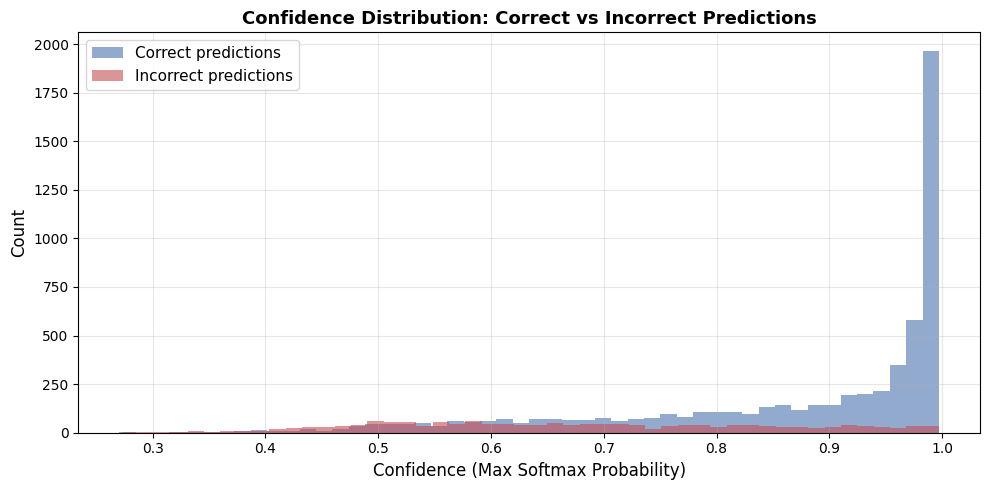

✅ Confidence distribution plot saved.


In [7]:
# ── Cell 7: Confidence Distribution Plot ─────────────────────────────────────
correct_mask = (calib_preds == calib_labels)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(calib_confidence[correct_mask],  bins=50, alpha=0.6,
        color="#4C72B0", label="Correct predictions")
ax.hist(calib_confidence[~correct_mask], bins=50, alpha=0.6,
        color="#C44E52", label="Incorrect predictions")
ax.set_xlabel("Confidence (Max Softmax Probability)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Confidence Distribution: Correct vs Incorrect Predictions", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CONFIDENCE_DIR}/confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confidence distribution plot saved.")


In [8]:
# ── Cell 8: Adaptive Threshold Calibration ───────────────────────────────────
# Strategy: find the threshold that maximises macro F1 on the calibration set
# while keeping coverage (fraction of samples predicted) above a minimum.
#
# Coverage = fraction of samples above threshold (not abstained)
# We sweep thresholds from 0.1 to 0.9 and track F1 vs coverage tradeoff

MIN_COVERAGE = 0.70  # at least 70% of samples must be predicted
thresholds   = np.arange(0.10, 0.95, 0.01)

results = []
for t in thresholds:
    mask     = calib_confidence >= t
    coverage = mask.mean()

    if coverage < MIN_COVERAGE:
        break

    if mask.sum() == 0:
        continue

    f1  = f1_score(calib_labels[mask], calib_preds[mask], average="macro")
    acc = (calib_preds[mask] == calib_labels[mask]).mean()
    results.append({
        "threshold": round(float(t), 2),
        "coverage":  float(coverage),
        "macro_f1":  float(f1),
        "accuracy":  float(acc),
        "n_predicted": int(mask.sum()),
        "n_abstained": int((~mask).sum()),
    })

results_arr = results
best = max(results_arr, key=lambda x: x["macro_f1"])
OPTIMAL_THRESHOLD = best["threshold"]

print(f"\n--- Threshold Calibration Results ---")
print(f"{'Threshold':>10} {'Coverage':>10} {'Macro F1':>10} {'Abstained':>10}")
print("-" * 45)
for r in results_arr[::5]:  # print every 5th row for brevity
    print(f"  {r['threshold']:>8.2f} {r['coverage']:>9.1%} {r['macro_f1']:>10.4f} {r['n_abstained']:>10}")

print(f"\n✅ Optimal threshold: {OPTIMAL_THRESHOLD}")
print(f"   Coverage at threshold: {best['coverage']:.1%}")
print(f"   Macro F1 at threshold: {best['macro_f1']:.4f}")
print(f"   Samples abstained:     {best['n_abstained']}")


--- Threshold Calibration Results ---
 Threshold   Coverage   Macro F1  Abstained
---------------------------------------------
      0.10    100.0%     0.7631          0
      0.15    100.0%     0.7631          0
      0.20    100.0%     0.7631          0
      0.25    100.0%     0.7631          0
      0.30     99.9%     0.7634          5
      0.35     99.7%     0.7642         24
      0.40     99.0%     0.7655         78
      0.45     97.5%     0.7714        188
      0.50     94.4%     0.7827        421
      0.55     90.2%     0.7951        746
      0.60     85.3%     0.8120       1112
      0.65     80.7%     0.8230       1465
      0.70     75.4%     0.8377       1867
      0.75     70.5%     0.8479       2234

✅ Optimal threshold: 0.74
   Coverage at threshold: 71.4%
   Macro F1 at threshold: 0.8485
   Samples abstained:     2169


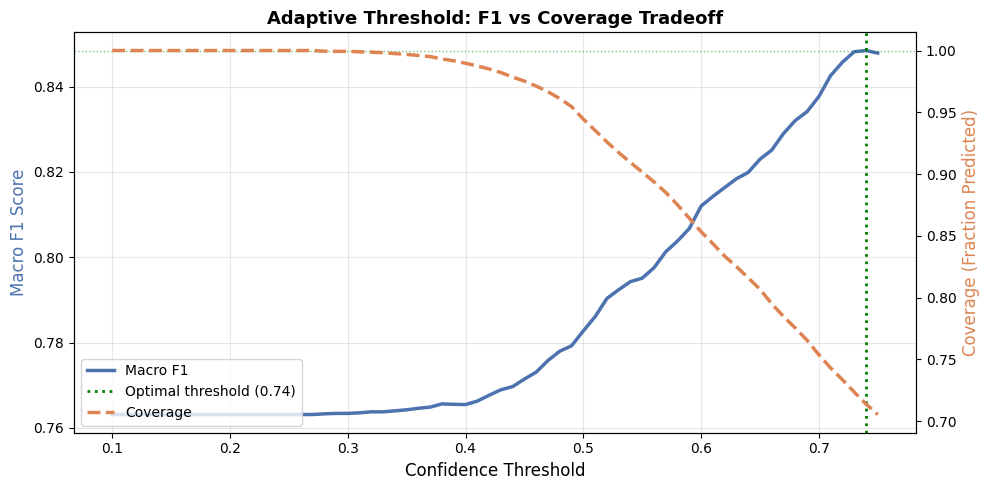

✅ Threshold tradeoff plot saved.


In [9]:
# ── Cell 9: F1 vs Coverage Tradeoff Plot ──────────────────────────────────────
thresh_vals   = [r["threshold"] for r in results_arr]
f1_vals       = [r["macro_f1"]  for r in results_arr]
coverage_vals = [r["coverage"]  for r in results_arr]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(thresh_vals, f1_vals,       color="#4C72B0", linewidth=2.5, label="Macro F1")
ax2.plot(thresh_vals, coverage_vals, color="#DD8452", linewidth=2.5,
         linestyle="--", label="Coverage")

ax1.axvline(OPTIMAL_THRESHOLD, color="green", linestyle=":", linewidth=2,
            label=f"Optimal threshold ({OPTIMAL_THRESHOLD})")
ax1.axhline(best["macro_f1"], color="green", linestyle=":", linewidth=1, alpha=0.5)

ax1.set_xlabel("Confidence Threshold", fontsize=12)
ax1.set_ylabel("Macro F1 Score", fontsize=12, color="#4C72B0")
ax2.set_ylabel("Coverage (Fraction Predicted)", fontsize=12, color="#DD8452")
ax1.set_title("Adaptive Threshold: F1 vs Coverage Tradeoff", fontsize=13, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc="lower left")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CONFIDENCE_DIR}/threshold_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Threshold tradeoff plot saved.")

In [10]:
# ── Cell 10: Evaluate on Held-Out Evaluation Set ─────────────────────────────
eval_confidence = eval_probs.max(axis=1)
above_thresh    = eval_confidence >= OPTIMAL_THRESHOLD
below_thresh    = ~above_thresh

print(f"\n--- Evaluation Set Results (threshold={OPTIMAL_THRESHOLD}) ---")
print(f"  Total samples     : {len(eval_labels)}")
print(f"  Predicted (above) : {above_thresh.sum()} ({above_thresh.mean():.1%})")
print(f"  Abstained (below) : {below_thresh.sum()} ({below_thresh.mean():.1%})")

# F1 on predicted samples only
f1_selective = f1_score(eval_labels[above_thresh], eval_preds[above_thresh], average="macro")
f1_baseline  = f1_score(eval_labels, eval_preds, average="macro")

print(f"\n  Macro F1 (all samples, no threshold) : {f1_baseline:.4f}")
print(f"  Macro F1 (predicted samples only)     : {f1_selective:.4f}")
print(f"  Improvement on predicted samples      : +{(f1_selective - f1_baseline)*100:.2f} F1 points")

print(f"\nClassification Report (predicted samples only):")
print(classification_report(
    eval_labels[above_thresh],
    eval_preds[above_thresh],
    target_names=CLASS_NAMES
))


--- Evaluation Set Results (threshold=0.74) ---
  Total samples     : 7580
  Predicted (above) : 5457 (72.0%)
  Abstained (below) : 2123 (28.0%)

  Macro F1 (all samples, no threshold) : 0.7733
  Macro F1 (predicted samples only)     : 0.8385
  Improvement on predicted samples      : +6.52 F1 points

Classification Report (predicted samples only):
                                        precision    recall  f1-score   support

                    caution_and_advice       0.83      0.89      0.86       362
      displaced_people_and_evacuations       0.93      0.96      0.94       360
     infrastructure_and_utility_damage       0.87      0.94      0.90       652
                injured_or_dead_people       0.95      0.98      0.96       691
               missing_or_found_people       0.91      0.83      0.87        35
                      not_humanitarian       0.76      0.72      0.74       277
            other_relevant_information       0.77      0.45      0.57       474
        

In [11]:
# ── Cell 11: Per-Class Abstention Analysis ────────────────────────────────────
# Shows which classes benefit most from selective prediction
print("\n--- Per-Class Abstention Analysis ---")
print(f"{'Class':<45} {'Abstained':>10} {'Abstain%':>10} {'F1 gain':>10}")
print("-" * 78)

per_class_gain = {}
for c in range(NUM_LABELS):
    class_mask   = (eval_labels == c)
    abstain_mask = class_mask & below_thresh
    predict_mask = class_mask & above_thresh

    abstain_rate = abstain_mask.sum() / class_mask.sum() if class_mask.sum() > 0 else 0

    if predict_mask.sum() > 0:
        f1_with    = f1_score(eval_labels[predict_mask], eval_preds[predict_mask],
                              average="macro", labels=[c], zero_division=0)
        f1_without = f1_score(eval_labels[class_mask],  eval_preds[class_mask],
                              average="macro", labels=[c], zero_division=0)
        gain = f1_with - f1_without
    else:
        gain = 0.0

    per_class_gain[CLASS_NAMES[c]] = gain
    print(f"  {CLASS_NAMES[c]:<43} {abstain_mask.sum():>10} {abstain_rate:>9.1%} {gain:>+10.4f}")



--- Per-Class Abstention Analysis ---
Class                                          Abstained   Abstain%    F1 gain
------------------------------------------------------------------------------
  caution_and_advice                                 196     35.1%    +0.0741
  displaced_people_and_evacuations                    47     11.5%    +0.0250
  infrastructure_and_utility_damage                  159     19.6%    +0.0390
  injured_or_dead_people                              43      5.9%    +0.0142
  missing_or_found_people                              6     14.6%    +0.0451
  not_humanitarian                                   318     53.4%    +0.0874
  other_relevant_information                         695     59.5%    -0.0612
  requests_or_urgent_needs                           112     44.6%    +0.0281
  rescue_volunteering_or_donation_effort             398     18.7%    +0.0342
  sympathy_and_support                               149     16.8%    +0.0440


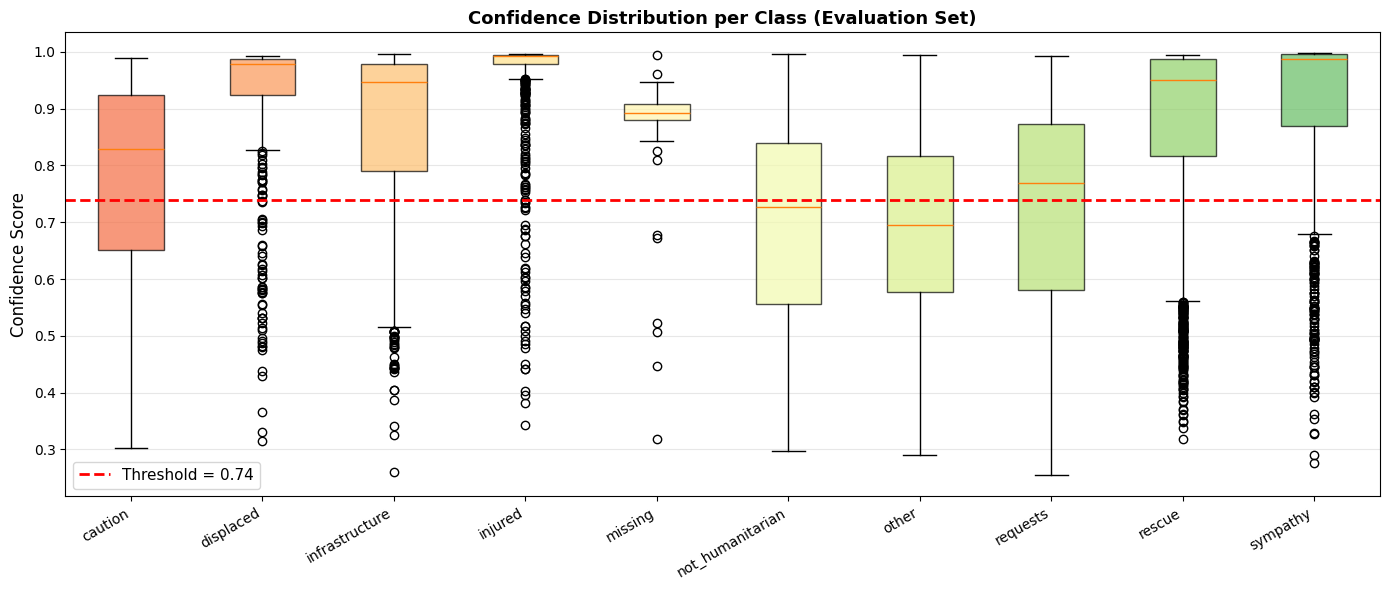

✅ Per-class confidence boxplot saved.


In [12]:
# ── Cell 12: Confidence by Class Boxplot ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

class_confidences = [
    eval_confidence[eval_labels == c] for c in range(NUM_LABELS)
]

bp = ax.boxplot(class_confidences, patch_artist=True, notch=False)
colors_box = plt.cm.RdYlGn(np.linspace(0.2, 0.8, NUM_LABELS))
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(OPTIMAL_THRESHOLD, color="red", linestyle="--", linewidth=2,
           label=f"Threshold = {OPTIMAL_THRESHOLD}")
ax.set_xticklabels(SHORT_NAMES, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Confidence Score", fontsize=12)
ax.set_title("Confidence Distribution per Class (Evaluation Set)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CONFIDENCE_DIR}/confidence_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Per-class confidence boxplot saved.")


In [13]:
# ── Cell 13: Save Results ─────────────────────────────────────────────────────
confidence_summary = {
    "optimal_threshold":     OPTIMAL_THRESHOLD,
    "calibration_set_size":  len(calib_idx),
    "evaluation_set_size":   len(eval_idx),
    "coverage_at_threshold": float(f"{above_thresh.mean():.4f}"),
    "abstained_count":       int(below_thresh.sum()),
    "macro_f1_all_samples":  float(f"{f1_baseline:.4f}"),
    "macro_f1_selective":    float(f"{f1_selective:.4f}"),
    "f1_improvement":        float(f"{(f1_selective - f1_baseline):.4f}"),
    "threshold_sweep":       results_arr,
}

with open(f"{CONFIDENCE_DIR}/confidence_summary.json", "w") as f:
    json.dump(confidence_summary, f, indent=4)

# Save threshold for use in frontend
np.save(f"{CONFIDENCE_DIR}/optimal_threshold.npy", np.array(OPTIMAL_THRESHOLD))

print(f"\n✅ All confidence results saved to {CONFIDENCE_DIR}")
print("\n" + "="*55)
print("NOVELTY 2 COMPLETE")
print("="*55)
print(f"  Optimal threshold        : {OPTIMAL_THRESHOLD}")
print(f"  Coverage                 : {above_thresh.mean():.1%}")
print(f"  Macro F1 (all)           : {f1_baseline:.4f}")
print(f"  Macro F1 (selective)     : {f1_selective:.4f}")
print(f"  Improvement              : +{(f1_selective - f1_baseline)*100:.2f} F1 points")
print("="*55)
print("\nNext step: Novelty 3 — Explainable Transformer-Based Classification")


✅ All confidence results saved to /content/drive/MyDrive/disaster_project/confidence_results

NOVELTY 2 COMPLETE
  Optimal threshold        : 0.74
  Coverage                 : 72.0%
  Macro F1 (all)           : 0.7733
  Macro F1 (selective)     : 0.8385
  Improvement              : +6.52 F1 points

Next step: Novelty 3 — Explainable Transformer-Based Classification
